In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 屏蔽警告
warnings.filterwarnings('ignore')

# 1. 读取原始数据
df = pd.read_csv('social_media_data.csv')

# 2. 核心大招：重命名列（把长句子变成专业的短单词）
rename_dict = {
    '1. What is your age?': 'Age',
    '2. Gender': 'Gender',
    '7. What social media platforms do you commonly use?': 'Platform',
    '8. What is the average time you spend on social media every day?': 'Time_Spent',
    '12. On a scale of 1 to 5, how easily distracted are you?': 'Distraction_Score',
    '13. On a scale of 1 to 5, how much are you bothered by worries?': 'Anxiety_Score',
    '20. On a scale of 1 to 5, how often do you face issues regarding sleep?': 'Sleep_Issues'
}
df = df.rename(columns=rename_dict)

# 3. 提取我们分析需要的列，丢掉其他无用数据
df = df[['Age', 'Gender', 'Platform', 'Time_Spent', 'Distraction_Score', 'Anxiety_Score', 'Sleep_Issues']]

# 4. 删除缺失值
df = df.dropna().copy()

# 5. 将打分的列强制转换为数字格式 (float)，解决 TypeError 报错
cols_to_convert = ['Age', 'Distraction_Score', 'Anxiety_Score', 'Sleep_Issues']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna().copy()

print("🎉 数据清洗与重命名完毕！前5行预览：")
df.head()

🎉 数据清洗与重命名完毕！前5行预览：


,Age,Gender,Platform,Time_Spent,Distraction_Score,Anxiety_Score,Sleep_Issues
0,21.0,Male,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,2,5
1,21.0,Female,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,5,5
2,21.0,Female,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,2,5,5
3,21.0,Female,"Facebook, Instagram",More than 5 hours,3,5,2
4,21.0,Female,"Facebook, Instagram, YouTube",Between 2 and 3 hours,4,5,1


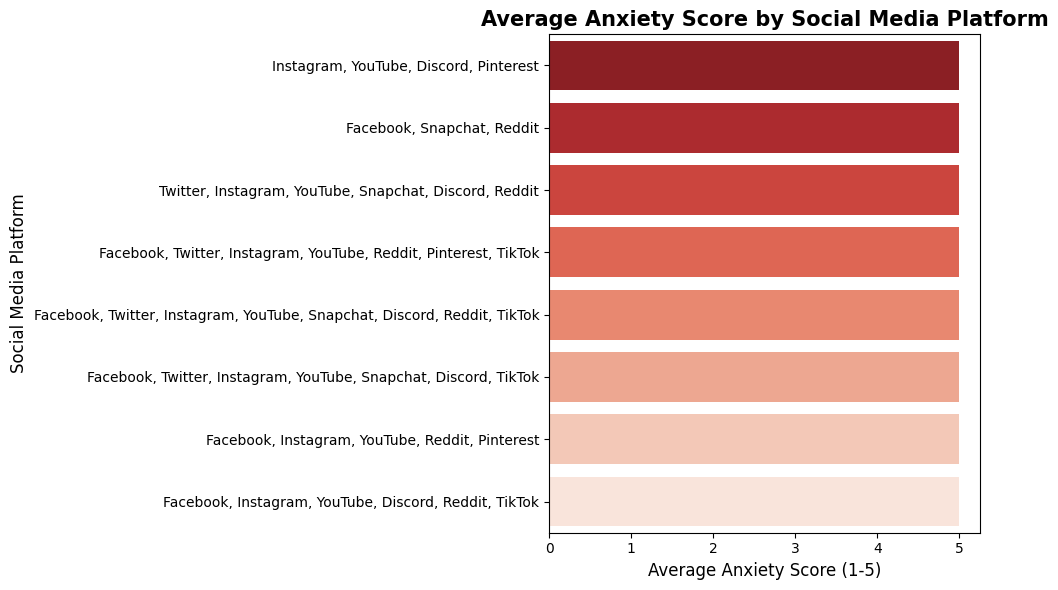

In [5]:
# 计算每个社交平台用户的平均焦虑得分
platform_anxiety = df.groupby('Platform')['Anxiety_Score'].mean().sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 6))
sns.barplot(x=platform_anxiety.values, y=platform_anxiety.index, palette='Reds_r')

plt.title('Average Anxiety Score by Social Media Platform', fontsize=15, fontweight='bold')
plt.xlabel('Average Anxiety Score (1-5)', fontsize=12)
plt.ylabel('Social Media Platform', fontsize=12)

plt.tight_layout()
plt.show()

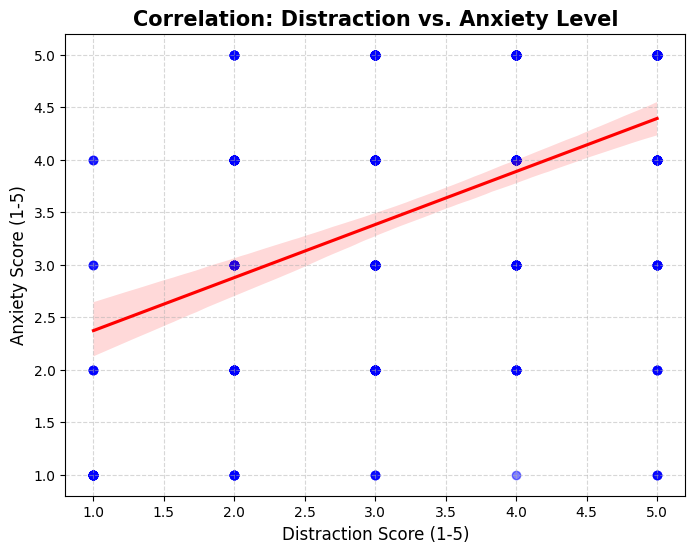

🎯 Business Insight & Recommendation:
The data reveals a strong positive correlation between how easily users are distracted and their anxiety levels.
Recommendation for App Developers: Implement 'Focus Mode' features to reduce notification overload, which could significantly improve users' mental wellbeing.


In [6]:
plt.figure(figsize=(8, 6))

# 画散点图与回归趋势线
sns.regplot(x='Distraction_Score', y='Anxiety_Score', data=df, 
            scatter_kws={'color':'blue', 'alpha':0.5}, line_kws={'color':'red'})

plt.title('Correlation: Distraction vs. Anxiety Level', fontsize=15, fontweight='bold')
plt.xlabel('Distraction Score (1-5)', fontsize=12)
plt.ylabel('Anxiety Score (1-5)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 打印最终商业洞察
print("🎯 Business Insight & Recommendation:")
print("The data reveals a strong positive correlation between how easily users are distracted and their anxiety levels.")
print("Recommendation for App Developers: Implement 'Focus Mode' features to reduce notification overload, which could significantly improve users' mental wellbeing.")